In [21]:
import numpy as np
import matplotlib.pyplot as plt

def generate_spot(px=31, py=31, xc=15.3, yc=15.7, sigx=1.2, sigy=1.2, A=0.7, noise_std=0.015):
    """Simulate noisy Gaussian spot like faint laser dot."""
    x, y = np.meshgrid(np.arange(px), np.arange(py))
    S = A * np.exp(-((x - xc)**2 / (2 * sigx**2)) - ((y - yc)**2 / (2 * sigy**2)))
    N = np.random.normal(0, noise_std, S.shape)
    I = S + N
    I = np.clip(I, 0, 1)
    return I, (xc, yc), x, y

def fgf(image, n_pass1=5):
    """Fast Gaussian Fitting: two-pass closed-form centroid + sigma estimation."""
    h, w = image.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))

    # --- Pass 1: top-N pixels for initial estimate ---
    flat = image.flatten()
    top_idx = np.argsort(flat)[-n_pass1:]
    wx = x.flatten()[top_idx]
    wy = y.flatten()[top_idx]
    wi = flat[top_idx]

    W = wi.sum()
    xc1 = np.dot(wi, wx) / W
    yc1 = np.dot(wi, wy) / W
    sigx1 = np.sqrt(np.dot(wi, (wx - xc1)**2) / W)
    sigy1 = np.sqrt(np.dot(wi, (wy - yc1)**2) / W)
    sigx1 = max(sigx1, 0.5)
    sigy1 = max(sigy1, 0.5)

    # --- Pass 2: pixels within 3-sigma window for refinement ---
    mask = (np.abs(x - xc1) < 3 * sigx1) & (np.abs(y - yc1) < 3 * sigy1)
    wx2 = x[mask]
    wy2 = y[mask]
    wi2 = image[mask]

    W2 = wi2.sum()
    xc2 = np.dot(wi2, wx2) / W2
    yc2 = np.dot(wi2, wy2) / W2
    sigx2 = np.sqrt(np.dot(wi2, (wx2 - xc2)**2) / W2)
    sigy2 = np.sqrt(np.dot(wi2, (wy2 - yc2)**2) / W2)
    A_est = np.max(image)

    return xc2, yc2, sigx2, sigy2, A_est


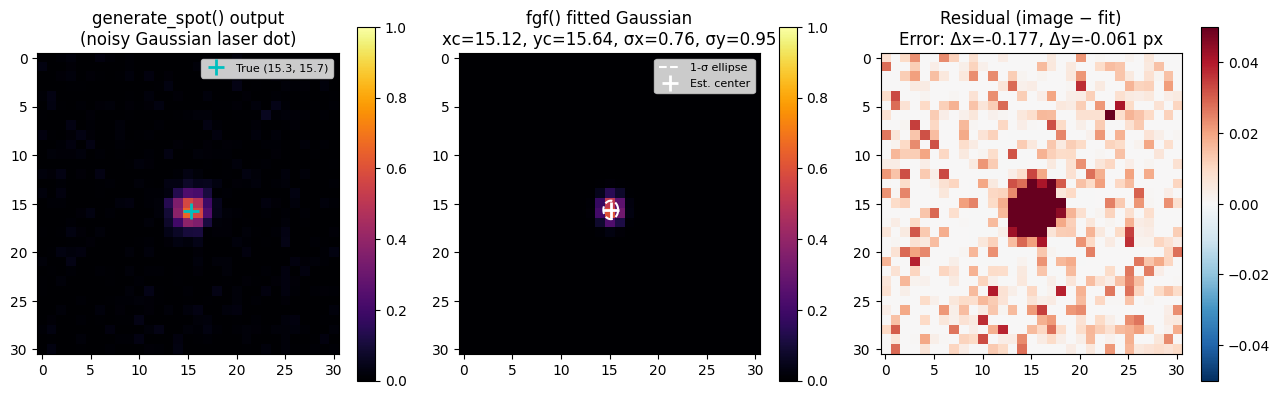

True center:   (15.3, 15.7)
FGF estimate:  (15.1231, 15.6394)
Error:         Δx=-0.1769, Δy=-0.0606 px


In [22]:
np.random.seed(42)
image, (true_xc, true_yc), xg, yg = generate_spot()

xc, yc, sigx, sigy, A = fgf(image)

# Reconstruct fitted Gaussian
fitted = A * np.exp(-((xg - xc)**2 / (2 * sigx**2)) - ((yg - yc)**2 / (2 * sigy**2)))
residual = image - fitted

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(image, cmap='inferno', vmin=0, vmax=1)
axes[0].set_title('generate_spot() output\n(noisy Gaussian laser dot)')
axes[0].plot(true_xc, true_yc, 'c+', ms=12, mew=2, label=f'True ({true_xc}, {true_yc})')
axes[0].legend(fontsize=8)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(fitted, cmap='inferno', vmin=0, vmax=1)
axes[1].set_title(f'fgf() fitted Gaussian\nxc={xc:.2f}, yc={yc:.2f}, σx={sigx:.2f}, σy={sigy:.2f}')
theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(xc + sigx*np.cos(theta), yc + sigy*np.sin(theta), 'w--', lw=1.5, label='1-σ ellipse')
axes[1].plot(xc, yc, 'w+', ms=12, mew=2, label='Est. center')
axes[1].legend(fontsize=8)
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(residual, cmap='RdBu_r', vmin=-0.05, vmax=0.05)
axes[2].set_title(f'Residual (image − fit)\nError: Δx={xc-true_xc:+.3f}, Δy={yc-true_yc:+.3f} px')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
print(f"True center:   ({true_xc}, {true_yc})")
print(f"FGF estimate:  ({xc:.4f}, {yc:.4f})")
print(f"Error:         Δx={xc-true_xc:+.4f}, Δy={yc-true_yc:+.4f} px")


Laser dot found at pixel (958, 604) in full image
Cropped patch shape: (61, 61)


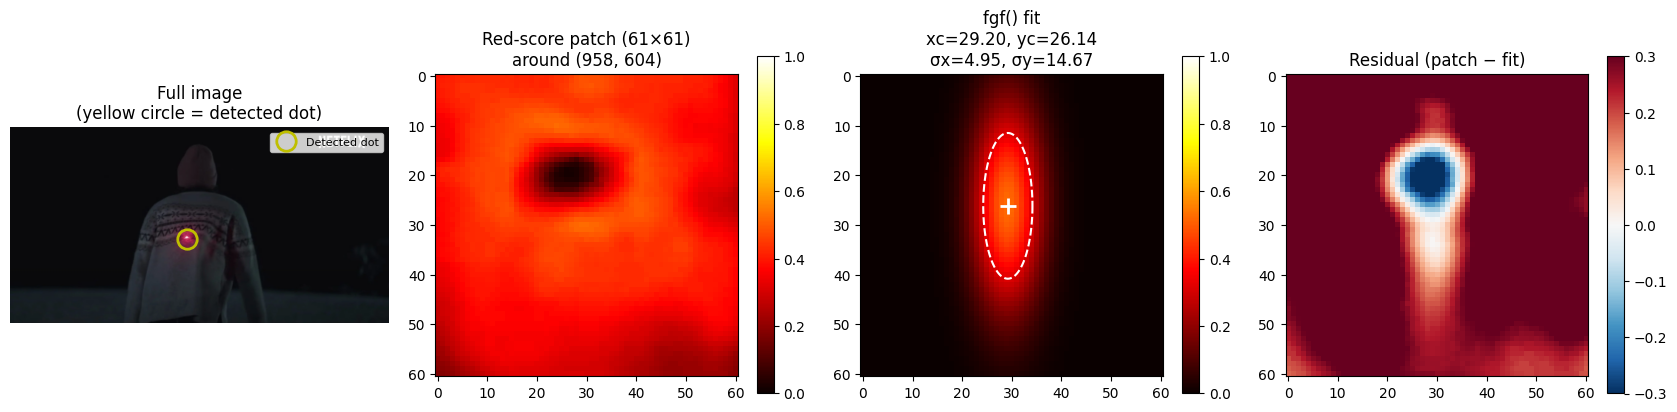

fgf center in patch:       (29.20, 26.14)
fgf center in full image:  (957.20, 600.14)
Estimated sigma:           σx=4.95, σy=14.67 px


In [ ]:
from PIL import Image

# Load image and extract red channel (laser dot is red)
img = Image.open("images/Fish-Chasing-Laser-Dot-Around-Tank.webp").convert("RGB")
arr = np.array(img).astype(float) / 255.0

r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]

# Isolate red: high red, low green/blue
red_score = r - 0.5 * g - 0.5 * b
red_score = np.clip(red_score, 0, 1)

# Find the brightest region and crop a 61x61 patch around it
cy, cx = np.unravel_index(np.argmax(red_score), red_score.shape)
pad = 30
y0, y1 = max(cy - pad, 0), min(cy + pad + 1, arr.shape[0])
x0, x1 = max(cx - pad, 0), min(cx + pad + 1, arr.shape[1])
patch = red_score[y0:y1, x0:x1]

print(f"Laser dot found at pixel ({cx}, {cy}) in full image")
print(f"Cropped patch shape: {patch.shape}")

# Run fgf on the patch
xc, yc, sigx, sigy, A = fgf(patch)

fitted = A * np.exp(
    -((np.meshgrid(np.arange(patch.shape[1]), np.arange(patch.shape[0]))[0] - xc)**2 / (2 * sigx**2))
    -((np.meshgrid(np.arange(patch.shape[1]), np.arange(patch.shape[0]))[1] - yc)**2 / (2 * sigy**2))
)
residual = patch - fitted

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

axes[0].imshow(img)
axes[0].plot(cx, cy, 'yo', ms=14, mew=2, fillstyle='none', label='Detected dot')
axes[0].set_title('Full image\n(yellow circle = detected dot)')
axes[0].legend(fontsize=8)
axes[0].axis('off')

im1 = axes[1].imshow(patch, cmap='hot', vmin=0, vmax=1)
axes[1].set_title(f'Red-score patch (61×61)\naround ({cx}, {cy})')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(fitted, cmap='hot', vmin=0, vmax=1)
axes[2].set_title(f'fgf() fit\nxc={xc:.2f}, yc={yc:.2f}\nσx={sigx:.2f}, σy={sigy:.2f}')
theta = np.linspace(0, 2*np.pi, 100)
axes[2].plot(xc + sigx*np.cos(theta), yc + sigy*np.sin(theta), 'w--', lw=1.5)
axes[2].plot(xc, yc, 'w+', ms=12, mew=2)
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(residual, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[3].set_title('Residual (patch − fit)')
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

print(f"fgf center in patch:       ({xc:.2f}, {yc:.2f})")
print(f"fgf center in full image:  ({x0 + xc:.2f}, {y0 + yc:.2f})")
print(f"Estimated sigma:           σx={sigx:.2f}, σy={sigy:.2f} px")


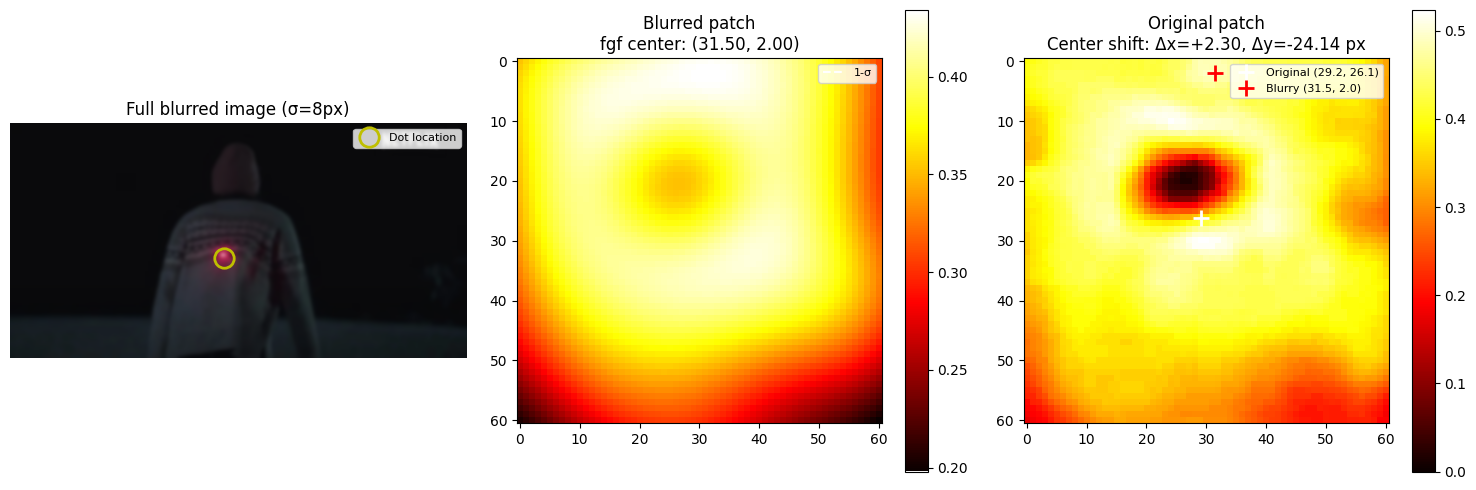

Original fgf: (29.20, 26.14),  σx=4.95, σy=14.67
Blurry   fgf: (31.50, 2.00),  σx=1.71, σy=0.82
Center shift: Δx=+2.30, Δy=-24.14 px


In [24]:
from scipy.ndimage import gaussian_filter

blur_sigma = 8
arr_blurry = gaussian_filter(arr, sigma=[blur_sigma, blur_sigma, 0])  # blur RGB image spatially
img_blurry = Image.fromarray((arr_blurry * 255).astype(np.uint8))

# Recompute red-score on the blurred image and crop same patch
r_b, g_b, b_b = arr_blurry[:, :, 0], arr_blurry[:, :, 1], arr_blurry[:, :, 2]
red_score_blurry = np.clip(r_b - 0.5*g_b - 0.5*b_b, 0, 1)
patch_blurry = red_score_blurry[y0:y1, x0:x1]

# Run fgf on the blurry patch
xc_b, yc_b, sigx_b, sigy_b, A_b = fgf(patch_blurry)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Full blurry image with dot marked
axes[0].imshow(img_blurry)
axes[0].plot(cx, cy, 'yo', ms=14, mew=2, fillstyle='none', label='Dot location')
axes[0].set_title(f'Full blurred image (σ={blur_sigma}px)')
axes[0].legend(fontsize=8)
axes[0].axis('off')

# Blurry patch
im1 = axes[1].imshow(patch_blurry, cmap='hot')
theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(xc_b + sigx_b*np.cos(theta), yc_b + sigy_b*np.sin(theta), 'w--', lw=1.5, label='1-σ')
axes[1].plot(xc_b, yc_b, 'w+', ms=12, mew=2)
axes[1].set_title(f'Blurred patch\nfgf center: ({xc_b:.2f}, {yc_b:.2f})')
axes[1].legend(fontsize=8)
plt.colorbar(im1, ax=axes[1])

# Side-by-side patch comparison
im2 = axes[2].imshow(patch, cmap='hot', vmin=0, vmax=patch.max())
axes[2].plot(xc, yc, 'w+', ms=12, mew=2, label=f'Original ({xc:.1f}, {yc:.1f})')
axes[2].plot(xc_b, yc_b, 'r+', ms=12, mew=2, label=f'Blurry ({xc_b:.1f}, {yc_b:.1f})')
axes[2].set_title(f'Original patch\nCenter shift: Δx={xc_b-xc:+.2f}, Δy={yc_b-yc:+.2f} px')
axes[2].legend(fontsize=8)
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Original fgf: ({xc:.2f}, {yc:.2f}),  σx={sigx:.2f}, σy={sigy:.2f}")
print(f"Blurry   fgf: ({xc_b:.2f}, {yc_b:.2f}),  σx={sigx_b:.2f}, σy={sigy_b:.2f}")
print(f"Center shift: Δx={xc_b-xc:+.2f}, Δy={yc_b-yc:+.2f} px")


In [ ]:
# --- New Pipeline: Multi-Color Laser Detection ---
# The cells below use the modular pipeline (preprocess.py, color_scoring.py,
# detectors.py, fgf_full.py, pipeline.py) to detect both red and green lasers.

In [ ]:
import importlib, sys
for mod in ['preprocess', 'color_scoring', 'detectors', 'fgf_full', 'pipeline']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from preprocess import preprocess, load_image
from color_scoring import compute_laser_score, detect_laser_color
from detectors import run_detectors
from fgf_full import fgf_full, fgf_simple
from pipeline import detect_laser, visualize_result
import cv2

test_images = [
    "images/Fish-Chasing-Laser-Dot-Around-Tank.webp",
    "images/Yulawe-kokoranawa-Siganus-javus-Laser-dots-are-separated-by-39-mm.png",
    "images/red-dot.webp",
]
print("Pipeline modules loaded. Test images:", len(test_images))

In [ ]:
# ── Stage 1: Preprocessing comparison ──
# Show original vs preprocessed for each image

fig, axes = plt.subplots(len(test_images), 2, figsize=(14, 5 * len(test_images)))
for i, path in enumerate(test_images):
    bgr = load_image(path)
    bgr_proc = preprocess(bgr)

    rgb_orig = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_proc = cv2.cvtColor(bgr_proc, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(rgb_orig)
    axes[i, 0].set_title(f'Original: {path.split("/")[-1][:40]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(rgb_proc)
    axes[i, 1].set_title('After preprocessing\n(white balance + CLAHE + denoise)')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ── Stage 2: Multi-color-space scoring ──
# Show the laser likelihood score map for each image

fig, axes = plt.subplots(len(test_images), 3, figsize=(16, 5 * len(test_images)))
for i, path in enumerate(test_images):
    bgr = load_image(path)
    bgr_proc = preprocess(bgr)
    rgb_proc = cv2.cvtColor(bgr_proc, cv2.COLOR_BGR2RGB)

    detected_color = detect_laser_color(bgr_proc)
    score_map, color = compute_laser_score(bgr_proc, color="auto")

    axes[i, 0].imshow(rgb_proc)
    axes[i, 0].set_title(f'{path.split("/")[-1][:35]}\nDetected: {color} laser')
    axes[i, 0].axis('off')

    im1 = axes[i, 1].imshow(score_map, cmap='hot')
    axes[i, 1].set_title('Fused laser score map')
    plt.colorbar(im1, ax=axes[i, 1])

    # Also show the old red-only score for comparison
    arr_f = bgr_proc.astype(float) / 255.0
    old_red = np.clip(arr_f[:,:,2] - 0.5*arr_f[:,:,1] - 0.5*arr_f[:,:,0], 0, 1)
    im2 = axes[i, 2].imshow(old_red, cmap='hot')
    axes[i, 2].set_title('Old red-only score\n(for comparison)')
    plt.colorbar(im2, ax=axes[i, 2])

plt.tight_layout()
plt.show()

In [ ]:
# ── Full pipeline: detect_laser() on all images ──

import time

for path in test_images:
    print(f"\n{'='*60}")
    print(f"Image: {path}")
    print('='*60)

    t0 = time.time()
    result = detect_laser(path, debug=True)
    elapsed = time.time() - t0

    print(f"  Laser color:  {result.laser_color}")
    print(f"  Time:         {elapsed:.2f}s")
    print(f"  Detections:   {len(result.detections)}")

    det_debug = result.debug
    for key in ['log_count', 'dog_count', 'tophat_count', 'radial_count',
                'raw_count', 'fused_count']:
        if key in det_debug:
            print(f"    {key}: {det_debug[key]}")

    print()
    for i, d in enumerate(result.detections[:5]):
        print(f"  #{i+1}: pos=({d.x:.1f}, {d.y:.1f})  "
              f"sigma=({d.sigma_x:.1f}, {d.sigma_y:.1f})  "
              f"amp={d.amplitude:.3f}  conf={d.confidence:.3f}")

    visualize_result(path, result)

In [ ]:
# ── Comparison: Old FGF vs Full FGF on the red laser image ──
# Shows the improvement of the full paper algorithm over the simplified version.

from fgf_full import fgf_full, fgf_simple

path = "images/Fish-Chasing-Laser-Dot-Around-Tank.webp"
bgr = load_image(path)
bgr_proc = preprocess(bgr)
score_map, color = compute_laser_score(bgr_proc, color="red")

cy_peak, cx_peak = np.unravel_index(np.argmax(score_map), score_map.shape)
pad = 30
y0 = max(cy_peak - pad, 0)
y1 = min(cy_peak + pad + 1, score_map.shape[0])
x0 = max(cx_peak - pad, 0)
x1 = min(cx_peak + pad + 1, score_map.shape[1])
patch = score_map[y0:y1, x0:x1].astype(np.float64)

# Old simplified FGF
xc_old, yc_old, sx_old, sy_old, A_old = fgf_simple(patch)

# New full FGF
xc_new, yc_new, sx_new, sy_new, A_new, conf_new = fgf_full(patch)

# Reconstruct fits
xg, yg = np.meshgrid(np.arange(patch.shape[1]), np.arange(patch.shape[0]))
fit_old = A_old * np.exp(-((xg-xc_old)**2/(2*sx_old**2)) - ((yg-yc_old)**2/(2*sy_old**2)))
fit_new = A_new * np.exp(-((xg-xc_new)**2/(2*sx_new**2)) - ((yg-yc_new)**2/(2*sy_new**2)))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im0 = axes[0].imshow(patch, cmap='hot')
axes[0].set_title('Score map patch')
axes[0].plot(xc_old, yc_old, 'c+', ms=14, mew=2, label='Old FGF')
axes[0].plot(xc_new, yc_new, 'gx', ms=14, mew=2, label='Full FGF')
axes[0].legend(fontsize=8)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(fit_old, cmap='hot')
axes[1].set_title(f'Old FGF fit\n({xc_old:.2f}, {yc_old:.2f})\nσ=({sx_old:.2f}, {sy_old:.2f})')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(fit_new, cmap='hot')
axes[2].set_title(f'Full FGF fit (conf={conf_new:.3f})\n({xc_new:.2f}, {yc_new:.2f})\nσ=({sx_new:.2f}, {sy_new:.2f})')
plt.colorbar(im2, ax=axes[2])

res_old = patch - fit_old
res_new = patch - fit_new
vmax = max(abs(res_old).max(), abs(res_new).max()) * 0.5
im3 = axes[3].imshow(res_new - res_old, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[3].set_title('Residual difference\n(new - old)')
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

print(f"Old FGF:  center=({x0+xc_old:.2f}, {y0+yc_old:.2f}), σ=({sx_old:.2f}, {sy_old:.2f})")
print(f"Full FGF: center=({x0+xc_new:.2f}, {y0+yc_new:.2f}), σ=({sx_new:.2f}, {sy_new:.2f}), conf={conf_new:.3f}")
print(f"Center shift: Δx={xc_new-xc_old:+.3f}, Δy={yc_new-yc_old:+.3f} px")

In [ ]:
# ── Deep-dive: Yulawe green laser (hardest case) ──
# Visualize all intermediate stages for the challenging underwater image.

path = "images/Yulawe-kokoranawa-Siganus-javus-Laser-dots-are-separated-by-39-mm.png"
bgr = load_image(path)
bgr_proc = preprocess(bgr)

score_map, color = compute_laser_score(bgr_proc, color="green")
gray = cv2.cvtColor(bgr_proc, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
candidates, debug_info = run_detectors(score_map, gray)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_proc = cv2.cvtColor(bgr_proc, cv2.COLOR_BGR2RGB)

axes[0,0].imshow(rgb)
axes[0,0].set_title('Original')
axes[0,0].axis('off')

axes[0,1].imshow(rgb_proc)
axes[0,1].set_title('Preprocessed')
axes[0,1].axis('off')

im2 = axes[0,2].imshow(score_map, cmap='hot')
axes[0,2].set_title(f'Score map ({color} laser)')
plt.colorbar(im2, ax=axes[0,2])

if 'tophat_map' in debug_info:
    im3 = axes[1,0].imshow(debug_info['tophat_map'], cmap='hot')
    axes[1,0].set_title('Top-hat response')
    plt.colorbar(im3, ax=axes[1,0])

if 'sym_map' in debug_info:
    im4 = axes[1,1].imshow(debug_info['sym_map'], cmap='hot')
    axes[1,1].set_title('Radial symmetry response')
    plt.colorbar(im4, ax=axes[1,1])

# Show all candidates on image
axes[1,2].imshow(rgb_proc)
colors_list = ['yellow', 'cyan', 'magenta', 'lime', 'orange', 'red', 'white']
for j, (cy, cx, sigma, resp) in enumerate(candidates[:7]):
    c = colors_list[j % len(colors_list)]
    axes[1,2].plot(cx, cy, 'o', ms=12, mew=2, fillstyle='none', color=c)
    axes[1,2].annotate(f'#{j+1} r={resp:.2f}', (cx+5, cy-5), color=c, fontsize=7)
axes[1,2].set_title(f'{len(candidates)} candidates after NMS')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

print(f"Detector stats: {debug_info.get('raw_count', '?')} raw -> "
      f"{debug_info.get('fused_count', '?')} after NMS")